In [35]:
import glob
import matplotlib.pyplot as plt
import pydicom
import numpy as np

In [29]:
data_path = '/workspaces/Roundel-Clinical/roundel/results/masks/dicoms/CHP-ALLAMA-1/'
files = sorted(glob.glob(f'{data_path}/**/*.dcm', recursive=True))

In [30]:
slices = max([int(file.split('slice_')[-1].split('_time')[0]) for file in files])
times = max([int(file.split('time_')[-1].split('.dcm')[0]) for file in files])

In [33]:
image = []
for slice in range(slices):
    image_slice = []
    for time in range(times):
        dcm = pydicom.dcmread(f'{data_path}/slice_{slice:02}_time_{time:02}.dcm')
        image_slice.append(dcm.pixel_array)
    image_slice = np.stack(image_slice, -1)
    image.append(image_slice)
image = np.stack(image, -2)


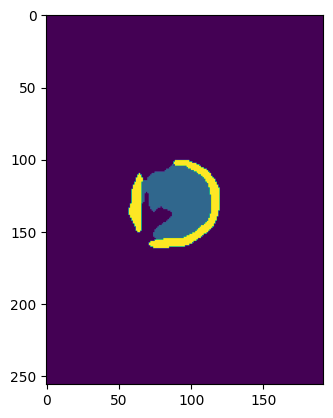

In [50]:
plt.imshow(image[:,:,7,24])

In [34]:
image.shape

(256, 192, 10, 27)